<a href="https://colab.research.google.com/github/Anmol007-007/ML-PROJECTS/blob/main/Student_success_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_csv("Student_success_dataset.csv")

Sample Rowws


In [17]:
print(df.head())

   Unnamed: 0  hours  Attendence  Past_Score Internet  Sleep_hours Is_Passed
0           0   4.19       39.71       55.11      yes         9.68        no
1           1   1.98       59.32       85.11      yes        10.47        no
2           2   5.12       35.95       67.72       no        10.48       yes
3           3   3.40       83.54       88.39      yes         8.75       yes
4           4   4.58       63.91       45.83      yes         5.92        no


Dataset Shape

In [18]:
print(f"Rows: {df.shape[0]} , Columns: {df.shape[1]}")

Rows: 1000 , Columns: 7


Dataset info

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1000 non-null   int64  
 1   hours        1000 non-null   float64
 2   Attendence   1000 non-null   float64
 3   Past_Score   1000 non-null   float64
 4   Internet     1000 non-null   object 
 5   Sleep_hours  1000 non-null   float64
 6   Is_Passed    1000 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB
None


Summary Statistics

In [20]:
print(df.describe(include = 'all'))

         Unnamed: 0        hours   Attendence   Past_Score Internet  \
count   1000.000000  1000.000000  1000.000000  1000.000000     1000   
unique          NaN          NaN          NaN          NaN        2   
top             NaN          NaN          NaN          NaN      yes   
freq            NaN          NaN          NaN          NaN      511   
mean     499.500000     5.604790    47.761220    59.936260      NaN   
std      288.819436     2.598925    27.824714    23.142413      NaN   
min        0.000000     1.000000     0.030000    20.060000      NaN   
25%      249.750000     3.385000    24.357500    40.037500      NaN   
50%      499.500000     5.615000    46.335000    59.175000      NaN   
75%      749.250000     7.780000    72.307500    80.367500      NaN   
max      999.000000    10.000000    97.960000    99.970000      NaN   

        Sleep_hours Is_Passed  
count   1000.000000      1000  
unique          NaN         2  
top             NaN        no  
freq            NaN

Missing values

In [21]:
print(df.isnull().sum())

Unnamed: 0     0
hours          0
Attendence     0
Past_Score     0
Internet       0
Sleep_hours    0
Is_Passed      0
dtype: int64


In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Is_Passed'] = le.fit_transform(df['Is_Passed'])
print(df.head())

print(df.info())
print(df.dtypes)

   Unnamed: 0  hours  Attendence  Past_Score  Internet  Sleep_hours  Is_Passed
0           0   4.19       39.71       55.11         1         9.68          0
1           1   1.98       59.32       85.11         1        10.47          0
2           2   5.12       35.95       67.72         0        10.48          1
3           3   3.40       83.54       88.39         1         8.75          1
4           4   4.58       63.91       45.83         1         5.92          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1000 non-null   int64  
 1   hours        1000 non-null   float64
 2   Attendence   1000 non-null   float64
 3   Past_Score   1000 non-null   float64
 4   Internet     1000 non-null   int64  
 5   Sleep_hours  1000 non-null   float64
 6   Is_Passed    1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 

In [23]:
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
df_scaled = df.copy()
feature = ['hours', 'Attendence', 'Past_Score', 'Sleep_hours']
df_scaled[feature] = scaler.fit_transform(df_scaled[feature])
x=  df_scaled[feature]
y=  df_scaled['Is_Passed']

X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state = 42)
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)




Classification Report

In [24]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.48      0.62      0.54       100
           1       0.46      0.33      0.39       100

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.46       200
weighted avg       0.47      0.47      0.46       200



Graph

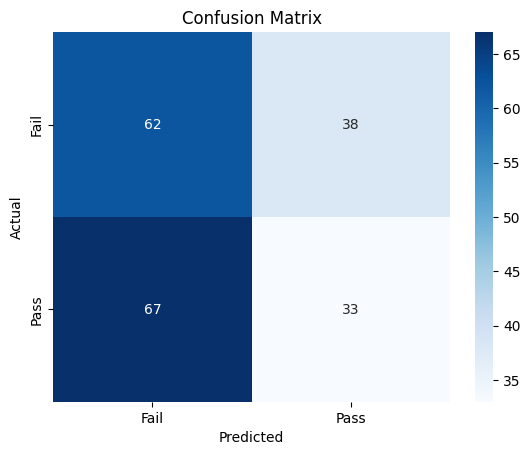

In [25]:
conf_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues' , xticklabels= ["Fail", "Pass"], yticklabels = ["Fail", "Pass"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [28]:
h = float(input("Enter the total Study Hours"))
att = float(input("Enter the Attendence"))
ps = float(input("Enter the Past Score"))
sh = float(input("Enter the Sleep Hours"))

input_df = pd.DataFrame([{'hours': h,'Attendence': att,'Past_Score': ps,'Sleep_hours':sh}])
input_scaled=  scaler.transform(input_df)

pridiction = model.predict(input_scaled)[0]

result = "Pass" if pridiction == 1 else "Fail"

print(f"The Student will {result}")


Enter the total Study Hours4
Enter the Attendence68
Enter the Past Score74
Enter the Sleep Hours9
The Student will Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
